In [34]:
!pip install -q librosa torchmetrics wandb soundfile

In [35]:
import os, random, warnings
import soundfile as sf
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import librosa
import librosa.display
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchmetrics.classification import MulticlassF1Score
import wandb
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import LabelEncoder
import itertools
from sklearn.metrics import confusion_matrix
warnings.filterwarnings('ignore')
print('All imports done!')

All imports done!


In [36]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
print('Seed set!')

Seed set!


In [37]:
SAMPLE_RATE   = 22050
DURATION      = 20
MAX_LENGTH    = SAMPLE_RATE * DURATION

N_MELS        = 128
N_FFT         = 2048
HOP_LENGTH    = 512
IMG_SIZE      = 224

BATCH_SIZE       = 24
GRAD_ACCUM       = 2
NUM_WORKERS      = 4
PREFETCH_FACTOR  = 4

EPOCHS_P1     = 5
EPOCHS_P2     = 10
LR_P1         = 1e-3
LR_P2         = 3e-4
WEIGHT_DECAY  = 0.01

PATIENCE_P1   = 3
PATIENCE_P2   = 4

TRAIN_SIZE    = 5000
NOISE_PROB    = 0.7
NOISE_LEVEL   = (0.03, 0.20)
TEMPO_PROB    = 0.2
TEMPO_RANGE   = (0.88, 1.12)
SPEC_AUGMENT  = True

N_TTA         = 5

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device     : {DEVICE}')
print(f'Duration   : {DURATION}s')
print(f'Train size : {TRAIN_SIZE}')
print(f'Epochs P1  : {EPOCHS_P1}  |  Epochs P2: {EPOCHS_P2}')
print(f'LR P1      : {LR_P1}  |  LR P2: {LR_P2}')
print(f'TTA crops  : {N_TTA}')

WANDB_PROJECT  = '23f2003621-t12026'
WANDB_RUN_NAME = f'custom_cnn_p1{EPOCHS_P1}_p2{EPOCHS_P2}_dur{DURATION}s'

Device     : cuda
Duration   : 20s
Train size : 5000
Epochs P1  : 5  |  Epochs P2: 10
LR P1      : 0.001  |  LR P2: 0.0003
TTA crops  : 5


In [38]:
wandb.init(
    project = WANDB_PROJECT,
    name    = WANDB_RUN_NAME,
    config  = {
        'model'        : 'CustomCNN',
        'duration'     : DURATION,
        'sample_rate'  : SAMPLE_RATE,
        'n_mels'       : N_MELS,
        'n_fft'        : N_FFT,
        'hop_length'   : HOP_LENGTH,
        'img_size'     : IMG_SIZE,
        'batch_size'   : BATCH_SIZE,
        'grad_accum'   : GRAD_ACCUM,
        'epochs_p1'    : EPOCHS_P1,
        'epochs_p2'    : EPOCHS_P2,
        'lr_p1'        : LR_P1,
        'lr_p2'        : LR_P2,
        'weight_decay' : WEIGHT_DECAY,
        'train_size'   : TRAIN_SIZE,
        'noise_prob'   : NOISE_PROB,
        'tempo_prob'   : TEMPO_PROB,
        'spec_augment' : SPEC_AUGMENT,
        'n_tta'        : N_TTA,
    }
)
print('WandB initialized!')

WandB initialized!


In [39]:
BASE_PATH      = '/kaggle/input/competitions/jan-2026-dl-gen-ai-project/messy_mashup'
GENRES_PATH    = os.path.join(BASE_PATH, 'genres_stems')
ESC_PATH       = os.path.join(BASE_PATH, 'ESC-50-master', 'audio')
REQUIRED_STEMS = ['drums.wav', 'vocals.wav', 'bass.wav', 'other.wav']

GENRES   = ['blues','classical','country','disco','hiphop',
            'jazz','metal','pop','reggae','rock']
label2id = {g: i for i, g in enumerate(GENRES)}
id2label = {i: g for g, i in label2id.items()}
NUM_LABELS = len(GENRES)

print('Paths set!')
print('label2id:', label2id)

Paths set!
label2id: {'blues': 0, 'classical': 1, 'country': 2, 'disco': 3, 'hiphop': 4, 'jazz': 5, 'metal': 6, 'pop': 7, 'reggae': 8, 'rock': 9}


In [40]:
def build_song_index():
    index = {}
    for genre in GENRES:
        genre_path = os.path.join(GENRES_PATH, genre)
        valid = []
        for folder in sorted(os.listdir(genre_path)):
            folder_path = os.path.join(genre_path, folder)
            if not os.path.isdir(folder_path):
                continue
            if all(os.path.exists(os.path.join(folder_path, s))
                   for s in REQUIRED_STEMS):
                valid.append(folder_path)
        index[genre] = valid
        print(f'  {genre}: {len(valid)} songs')
    return index

song_index = build_song_index()
print('Song index built!')

  blues: 100 songs
  classical: 100 songs
  country: 100 songs
  disco: 100 songs
  hiphop: 100 songs
  jazz: 100 songs
  metal: 100 songs
  pop: 100 songs
  reggae: 100 songs
  rock: 100 songs
Song index built!


In [41]:
train_index = {}
val_index   = {}

for genre in GENRES:
    songs = song_index[genre][:]
    random.shuffle(songs)
    split = int(0.85 * len(songs))
    train_index[genre] = songs[:split]
    val_index[genre]   = songs[split:]
    print(f'  {genre} -> Train: {len(train_index[genre])}, Val: {len(val_index[genre])}')

print('\nTrain/Val split done!')

  blues -> Train: 85, Val: 15
  classical -> Train: 85, Val: 15
  country -> Train: 85, Val: 15
  disco -> Train: 85, Val: 15
  hiphop -> Train: 85, Val: 15
  jazz -> Train: 85, Val: 15
  metal -> Train: 85, Val: 15
  pop -> Train: 85, Val: 15
  reggae -> Train: 85, Val: 15
  rock -> Train: 85, Val: 15

Train/Val split done!


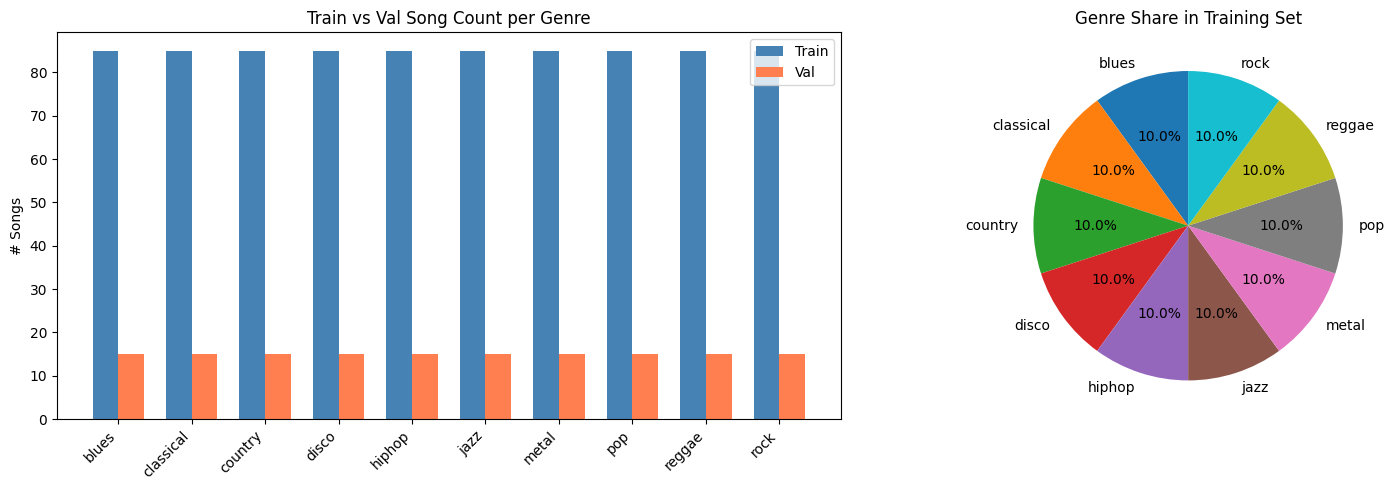

Train total: 850 | Val total: 150


In [42]:

train_counts = {g: len(train_index[g]) for g in GENRES}
val_counts   = {g: len(val_index[g])   for g in GENRES}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))


x = np.arange(len(GENRES))
w = 0.35
axes[0].bar(x - w/2, train_counts.values(), w, label='Train', color='steelblue')
axes[0].bar(x + w/2, val_counts.values(),   w, label='Val',   color='coral')
axes[0].set_xticks(x); axes[0].set_xticklabels(GENRES, rotation=45, ha='right')
axes[0].set_title('Train vs Val Song Count per Genre')
axes[0].set_ylabel('# Songs'); axes[0].legend()


axes[1].pie(train_counts.values(), labels=GENRES, autopct='%1.1f%%',
            startangle=90, colors=sns.color_palette('tab10', len(GENRES)))
axes[1].set_title('Genre Share in Training Set')

plt.tight_layout(); plt.show()
print("Train total:", sum(train_counts.values()), "| Val total:", sum(val_counts.values()))

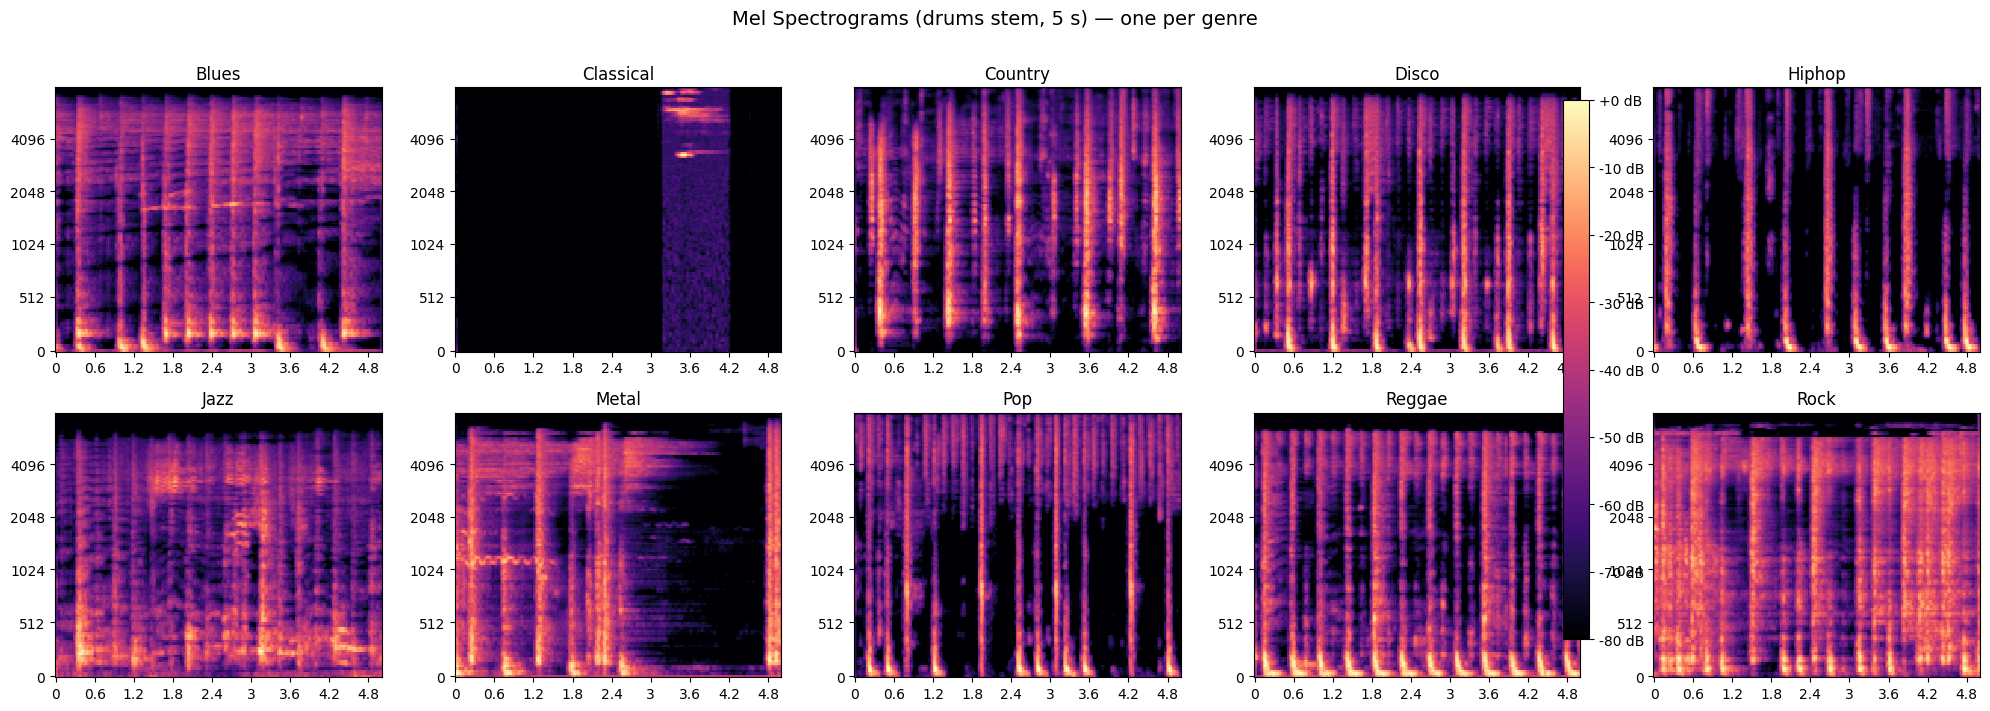

In [43]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
axes = axes.flatten()

for i, genre in enumerate(GENRES):
    
    song_path = train_index[genre][0]
    audio, sr = librosa.load(os.path.join(song_path, 'drums.wav'),
                              sr=SAMPLE_RATE, duration=5.0, mono=True)
    mel = librosa.feature.melspectrogram(y=audio, sr=sr,
                                          n_mels=N_MELS, n_fft=N_FFT,
                                          hop_length=HOP_LENGTH)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    img = librosa.display.specshow(mel_db, sr=sr, hop_length=HOP_LENGTH,
                                   x_axis='time', y_axis='mel', ax=axes[i],
                                   fmax=8000)
    axes[i].set_title(genre.capitalize(), fontsize=12)
    axes[i].set_xlabel(''); axes[i].set_ylabel('')

fig.suptitle('Mel Spectrograms (drums stem, 5 s) — one per genre', fontsize=14, y=1.01)
plt.colorbar(img, ax=axes, format='%+2.0f dB')
plt.tight_layout(); plt.show()

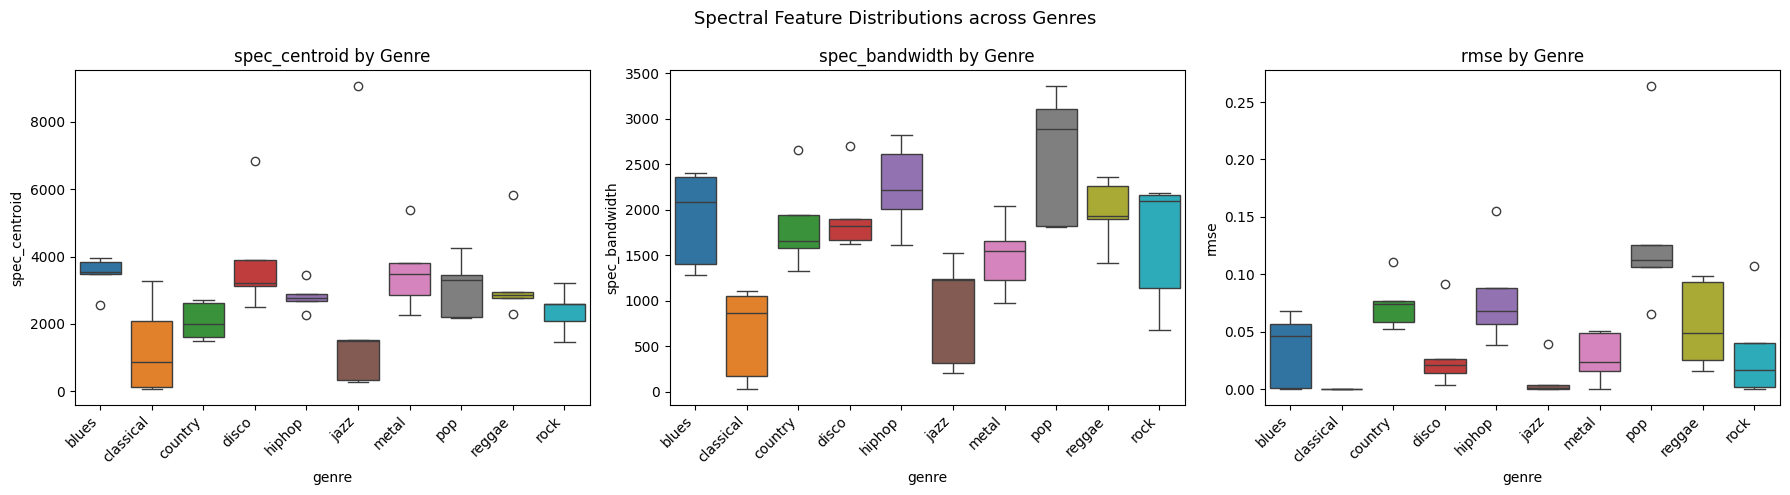

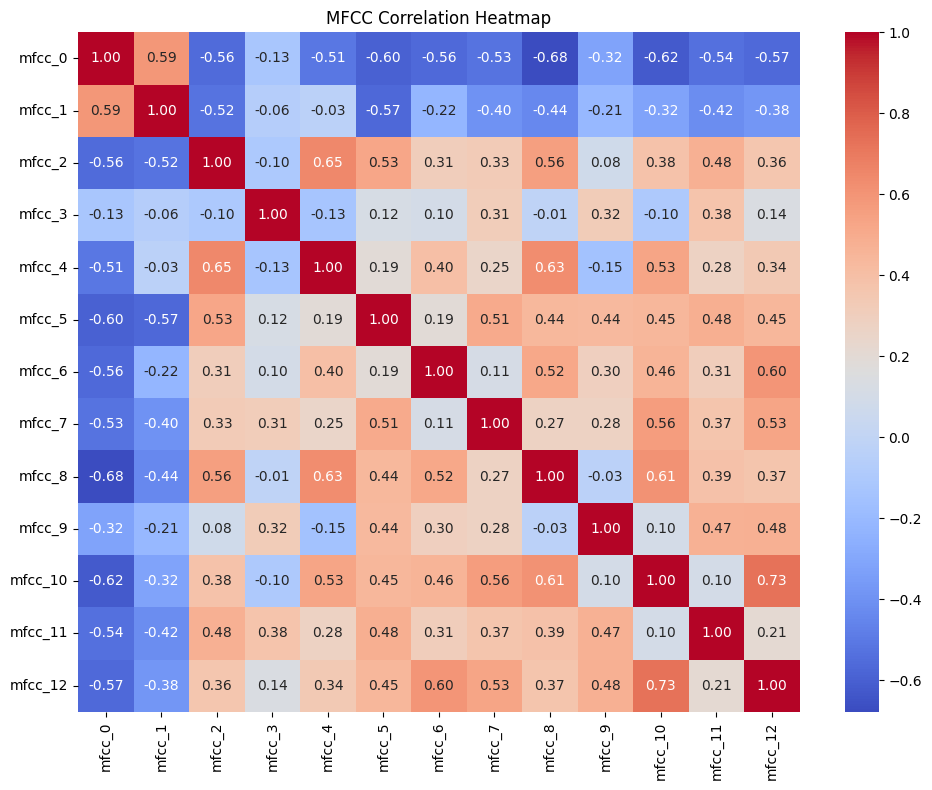

In [44]:

feature_rows = []
for genre in GENRES:
    for song_path in train_index[genre][:5]:            # 5 songs per genre
        try:
            audio, sr = librosa.load(os.path.join(song_path, 'vocals.wav'),
                                     sr=SAMPLE_RATE, duration=10.0, mono=True)
            mfccs       = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13).mean(axis=1)
            zcr         = librosa.feature.zero_crossing_rate(audio).mean()
            spec_cent   = librosa.feature.spectral_centroid(y=audio, sr=sr).mean()
            spec_bw     = librosa.feature.spectral_bandwidth(y=audio, sr=sr).mean()
            rmse        = librosa.feature.rms(y=audio).mean()
            row = {'genre': genre, 'zcr': zcr, 'spec_centroid': spec_cent,
                   'spec_bandwidth': spec_bw, 'rmse': rmse}
            row.update({f'mfcc_{j}': mfccs[j] for j in range(13)})
            feature_rows.append(row)
        except Exception:
            pass

eda_df = pd.DataFrame(feature_rows)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feat in zip(axes, ['spec_centroid', 'spec_bandwidth', 'rmse']):
    sns.boxplot(data=eda_df, x='genre', y=feat, ax=ax,
                palette='tab10', order=GENRES)
    ax.set_xticklabels(GENRES, rotation=45, ha='right')
    ax.set_title(f'{feat} by Genre')
plt.suptitle('Spectral Feature Distributions across Genres', fontsize=13)
plt.tight_layout(); plt.show()


mfcc_cols = [f'mfcc_{j}' for j in range(13)]
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(eda_df[mfcc_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', ax=ax)
ax.set_title('MFCC Correlation Heatmap'); plt.tight_layout(); plt.show()

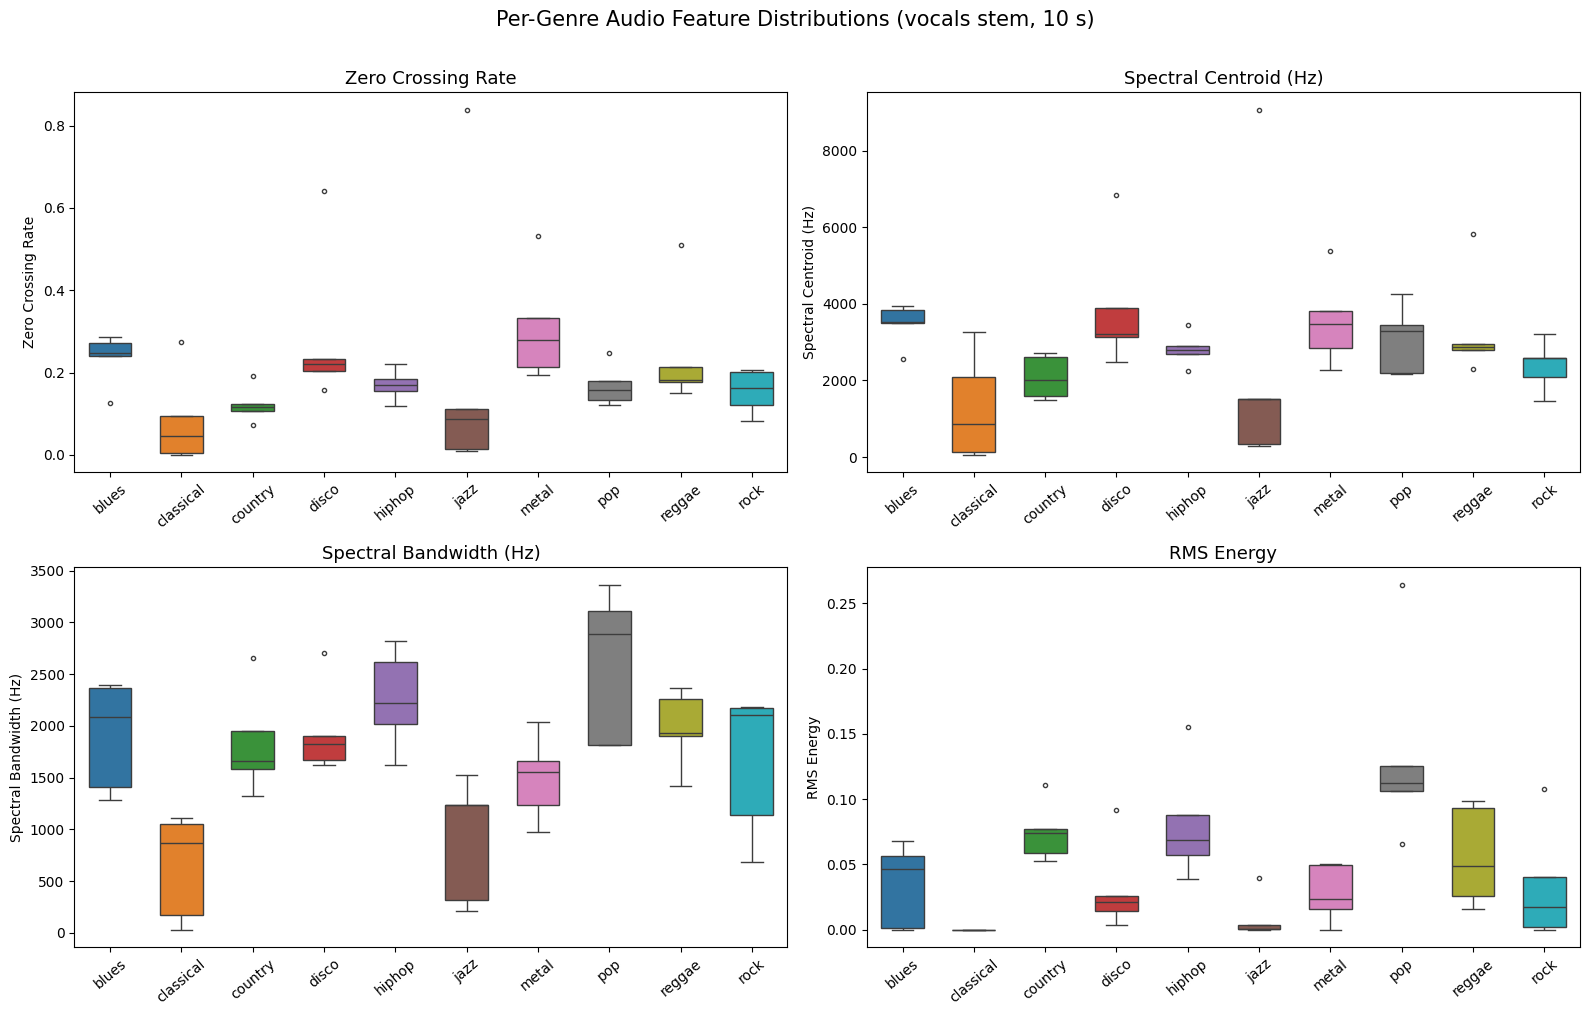

Key takeaways:
  Zero Crossing Rate: highest → metal   |   lowest → classical
  Spectral Centroid (Hz): highest → disco   |   lowest → classical
  Spectral Bandwidth (Hz): highest → pop   |   lowest → classical
  RMS Energy: highest → pop   |   lowest → classical


In [66]:
features_to_plot = ['zcr', 'spec_centroid', 'spec_bandwidth', 'rmse']
feature_labels   = ['Zero Crossing Rate', 'Spectral Centroid (Hz)',
                    'Spectral Bandwidth (Hz)', 'RMS Energy']
 
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
palette = sns.color_palette('tab10', len(GENRES))
 
for i, (feat, label) in enumerate(zip(features_to_plot, feature_labels)):
    sns.boxplot(
        data    = eda_df,
        x       = 'genre',
        y       = feat,
        order   = GENRES,
        palette = palette,
        ax      = axes[i],
        width   = 0.6,
        fliersize = 3,
    )
    axes[i].set_title(label, fontsize=13)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(label, fontsize=10)
    axes[i].tick_params(axis='x', rotation=40)
 
fig.suptitle('Per-Genre Audio Feature Distributions (vocals stem, 10 s)',
             fontsize=15, y=1.01)
plt.tight_layout()
plt.show()
 
print("Key takeaways:")
for feat, label in zip(features_to_plot, feature_labels):
    top    = eda_df.groupby('genre')[feat].mean().idxmax()
    bottom = eda_df.groupby('genre')[feat].mean().idxmin()
    print(f"  {label}: highest → {top}   |   lowest → {bottom}")

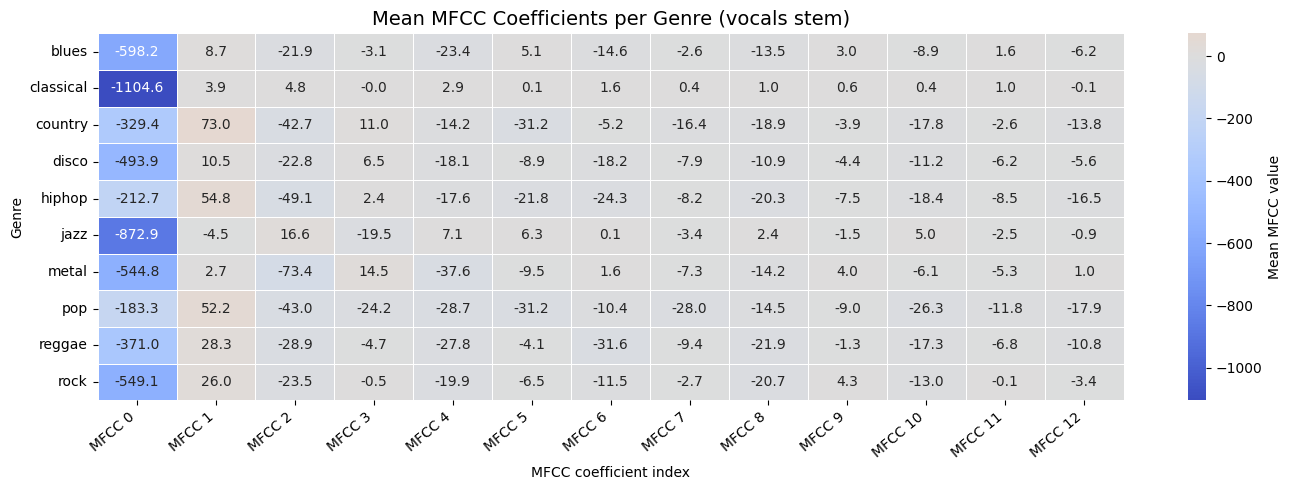


Most similar genre pairs (low MFCC distance):
  hiphop ↔ pop  :  50.25
  blues ↔ rock  :  54.39
  disco ↔ rock  :  60.23
Most distinct genre pairs:
  classical ↔ country  :  781.38
  classical ↔ hiphop  :  896.62
  classical ↔ pop  :  926.51


In [67]:
mfcc_cols  = [f'mfcc_{j}' for j in range(13)]
mfcc_means = eda_df.groupby('genre')[mfcc_cols].mean()   # shape (10, 13)
 
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    mfcc_means,
    annot   = True,
    fmt     = '.1f',
    cmap    = 'coolwarm',
    center  = 0,
    ax      = ax,
    linewidths = 0.4,
    cbar_kws   = {'label': 'Mean MFCC value'},
)
ax.set_title('Mean MFCC Coefficients per Genre (vocals stem)', fontsize=14)
ax.set_xlabel('MFCC coefficient index')
ax.set_ylabel('Genre')
ax.set_xticklabels([f'MFCC {j}' for j in range(13)], rotation=40, ha='right')
plt.tight_layout()
plt.show()
 

from scipy.spatial.distance import cdist
dist_matrix = pd.DataFrame(
    cdist(mfcc_means.values, mfcc_means.values, metric='euclidean'),
    index   = mfcc_means.index,
    columns = mfcc_means.index,
)
print("\nMost similar genre pairs (low MFCC distance):")
pairs = []
for g1 in GENRES:
    for g2 in GENRES:
        if g1 < g2:
            pairs.append((g1, g2, dist_matrix.loc[g1, g2]))
pairs.sort(key=lambda x: x[2])
for g1, g2, d in pairs[:3]:
    print(f"  {g1} ↔ {g2}  :  {d:.2f}")
print("Most distinct genre pairs:")
for g1, g2, d in pairs[-3:]:
    print(f"  {g1} ↔ {g2}  :  {d:.2f}")
 
 

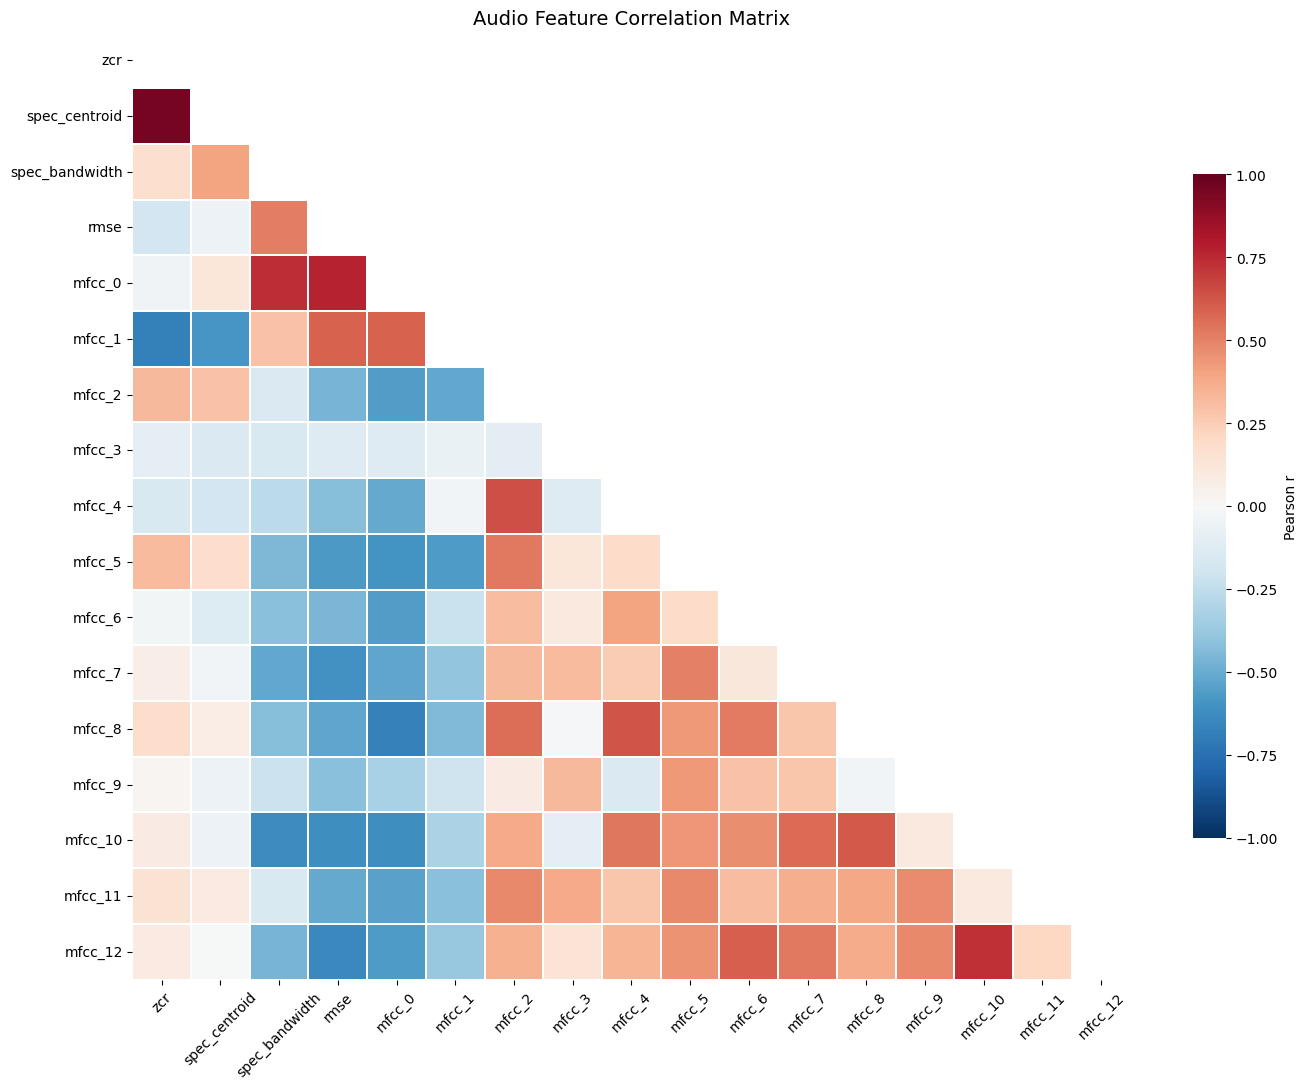

Top 5 positively correlated feature pairs:
       feat_a         feat_b        r
spec_centroid            zcr 0.958957
       mfcc_0           rmse 0.772518
       mfcc_0 spec_bandwidth 0.741875
      mfcc_12        mfcc_10 0.731196
       mfcc_4         mfcc_2 0.647779

Top 5 negatively correlated feature pairs:
 feat_a         feat_b         r
 mfcc_1            zcr -0.684326
 mfcc_8         mfcc_0 -0.677545
mfcc_12           rmse -0.645814
mfcc_10 spec_bandwidth -0.631006
mfcc_10         mfcc_0 -0.624065


In [68]:

numeric_cols = ['zcr', 'spec_centroid', 'spec_bandwidth', 'rmse'] + mfcc_cols
corr = eda_df[numeric_cols].corr()
 
fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))   # upper triangle mask
sns.heatmap(
    corr,
    mask       = mask,
    cmap       = 'RdBu_r',
    center     = 0,
    vmin       = -1, vmax = 1,
    annot      = False,
    linewidths = 0.3,
    ax         = ax,
    cbar_kws   = {'label': 'Pearson r', 'shrink': 0.7},
)
ax.set_title('Audio Feature Correlation Matrix', fontsize=14)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()
 
corr_pairs = (
    corr.where(mask == False)   # keep lower triangle only
        .stack()
        .reset_index()
)
corr_pairs.columns = ['feat_a', 'feat_b', 'r']
corr_pairs = corr_pairs[corr_pairs['feat_a'] != corr_pairs['feat_b']]
corr_pairs['abs_r'] = corr_pairs['r'].abs()
 
print("Top 5 positively correlated feature pairs:")
print(corr_pairs.nlargest(5, 'r')[['feat_a', 'feat_b', 'r']].to_string(index=False))
print("\nTop 5 negatively correlated feature pairs:")
print(corr_pairs.nsmallest(5, 'r')[['feat_a', 'feat_b', 'r']].to_string(index=False))

In [45]:
def extract_features(audio, sr):
    """Extract a fixed-length feature vector from raw audio."""
    features = []

    
    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=20)
    features.extend(mfccs.mean(axis=1).tolist())
    features.extend(mfccs.std(axis=1).tolist())

    
    chroma = librosa.feature.chroma_stft(y=audio, sr=sr, n_chroma=12)
    features.extend(chroma.mean(axis=1).tolist())
    features.extend(chroma.std(axis=1).tolist())

    
    features.append(librosa.feature.spectral_centroid(y=audio, sr=sr).mean())
    features.append(librosa.feature.spectral_centroid(y=audio, sr=sr).std())
    features.append(librosa.feature.spectral_bandwidth(y=audio, sr=sr).mean())
    features.append(librosa.feature.spectral_rolloff(y=audio, sr=sr).mean())
    features.append(librosa.feature.zero_crossing_rate(audio).mean())
    features.append(librosa.feature.rms(y=audio).mean())

    
    mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128,
                                          n_fft=N_FFT, hop_length=HOP_LENGTH)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    features.extend(mel_db.mean(axis=1).tolist())
    features.extend(mel_db.std(axis=1).tolist())

    return np.array(features, dtype=np.float32)

def extract_song_features(song_path, stems=REQUIRED_STEMS, duration=10.0):
    """Concatenate features from all stems for one song."""
    all_feats = []
    for stem in stems:
        try:
            audio, sr = librosa.load(os.path.join(song_path, stem),
                                     sr=SAMPLE_RATE, duration=duration, mono=True)
            all_feats.append(extract_features(audio, sr))
        except Exception:
            all_feats.append(np.zeros(326, dtype=np.float32))  # fallback zeros
    return np.concatenate(all_feats)

print(f"Feature vector size per song: {extract_song_features(train_index['blues'][0]).shape[0]}")

Feature vector size per song: 1304


In [46]:

wandb.init(
    project = WANDB_PROJECT,
    name    = f"{WANDB_RUN_NAME}_lgbm",
    config  = {
        'model':          'LightGBM',
        'n_per_genre':    100,
        'n_estimators':   300,
        'learning_rate':  0.05,
        'num_leaves':     63,
        'subsample':      0.8,
        'colsample_bytree': 0.8,
        'n_folds':        5,
        'stems':          REQUIRED_STEMS,
        'duration':       10.0,
        'sample_rate':    SAMPLE_RATE,
    }
)

N_PER_GENRE = 30

X_rows, y_rows = [], []
for genre in GENRES:
    songs = train_index[genre][:N_PER_GENRE] + val_index[genre][:max(1, N_PER_GENRE//5)]
    for song_path in tqdm(songs, desc=f'{genre}'):
        try:
            feats = extract_song_features(song_path)
            X_rows.append(feats)
            y_rows.append(label2id[genre])
        except Exception as e:
            print(f"  skip {song_path}: {e}")

X = np.stack(X_rows)
y = np.array(y_rows)
print(f"\nDataset shape: X={X.shape}, y={y.shape}")
wandb.log({'lgbm_dataset_size': len(y)})

rock: 100%|██████████| 36/36 [00:21<00:00,  1.70it/s]


Dataset shape: X=(360, 1304), y=(360,)


In [47]:

lgbm_params = {
    'objective':         'multiclass',
    'num_class':         NUM_LABELS,
    'metric':            'multi_logloss',
    'n_estimators':      300,
    'learning_rate':     0.05,
    'num_leaves':        63,
    'max_depth':         -1,
    'min_child_samples': 10,
    'subsample':         0.8,
    'colsample_bytree':  0.8,
    'reg_alpha':         0.1,
    'reg_lambda':        0.1,
    'n_jobs':            -1,
    'verbosity':         -1,
    'random_state':      42,
}

skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof    = np.zeros((len(y), NUM_LABELS))
models = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_va = X[tr_idx], X[va_idx]
    y_tr, y_va = y[tr_idx], y[va_idx]

    clf = lgb.LGBMClassifier(**lgbm_params)
    clf.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        callbacks=[lgb.early_stopping(30, verbose=False),
                   lgb.log_evaluation(50)],
    )
    oof[va_idx] = clf.predict_proba(X_va)
    models.append(clf)

    fold_f1 = f1_score(y_va, oof[va_idx].argmax(axis=1), average='macro')
    print(f"  Fold {fold} Macro-F1: {fold_f1:.4f}")

    # ── log per-fold metrics ──
    wandb.log({
        f'lgbm_fold{fold}_macro_f1':      fold_f1,
        f'lgbm_fold{fold}_best_iteration': clf.best_iteration_,
    })

oof_preds  = oof.argmax(axis=1)
overall_f1 = f1_score(y, oof_preds, average='macro')
print(f"\n=== OOF Macro-F1: {overall_f1:.4f} ===")
print(classification_report(y, oof_preds, target_names=GENRES))


wandb.log({'lgbm_oof_macro_f1': overall_f1})
wandb.summary['lgbm_oof_macro_f1'] = overall_f1

[50]	valid_0's multi_logloss: 1.16949
[100]	valid_0's multi_logloss: 1.13737
  Fold 1 Macro-F1: 0.5773
[50]	valid_0's multi_logloss: 1.05567
[100]	valid_0's multi_logloss: 0.99546
[150]	valid_0's multi_logloss: 0.992875
  Fold 2 Macro-F1: 0.7099
[50]	valid_0's multi_logloss: 1.39376
[100]	valid_0's multi_logloss: 1.3879
  Fold 3 Macro-F1: 0.5596
[50]	valid_0's multi_logloss: 1.16621
[100]	valid_0's multi_logloss: 1.0854
[150]	valid_0's multi_logloss: 1.07175
[200]	valid_0's multi_logloss: 1.07093
  Fold 4 Macro-F1: 0.6644
[50]	valid_0's multi_logloss: 1.21858
[100]	valid_0's multi_logloss: 1.12765
  Fold 5 Macro-F1: 0.5838

=== OOF Macro-F1: 0.6254 ===
              precision    recall  f1-score   support

       blues       0.49      0.50      0.49        36
   classical       0.86      0.89      0.88        36
     country       0.66      0.64      0.65        36
       disco       0.65      0.61      0.63        36
      hiphop       0.74      0.69      0.71        36
        jazz  

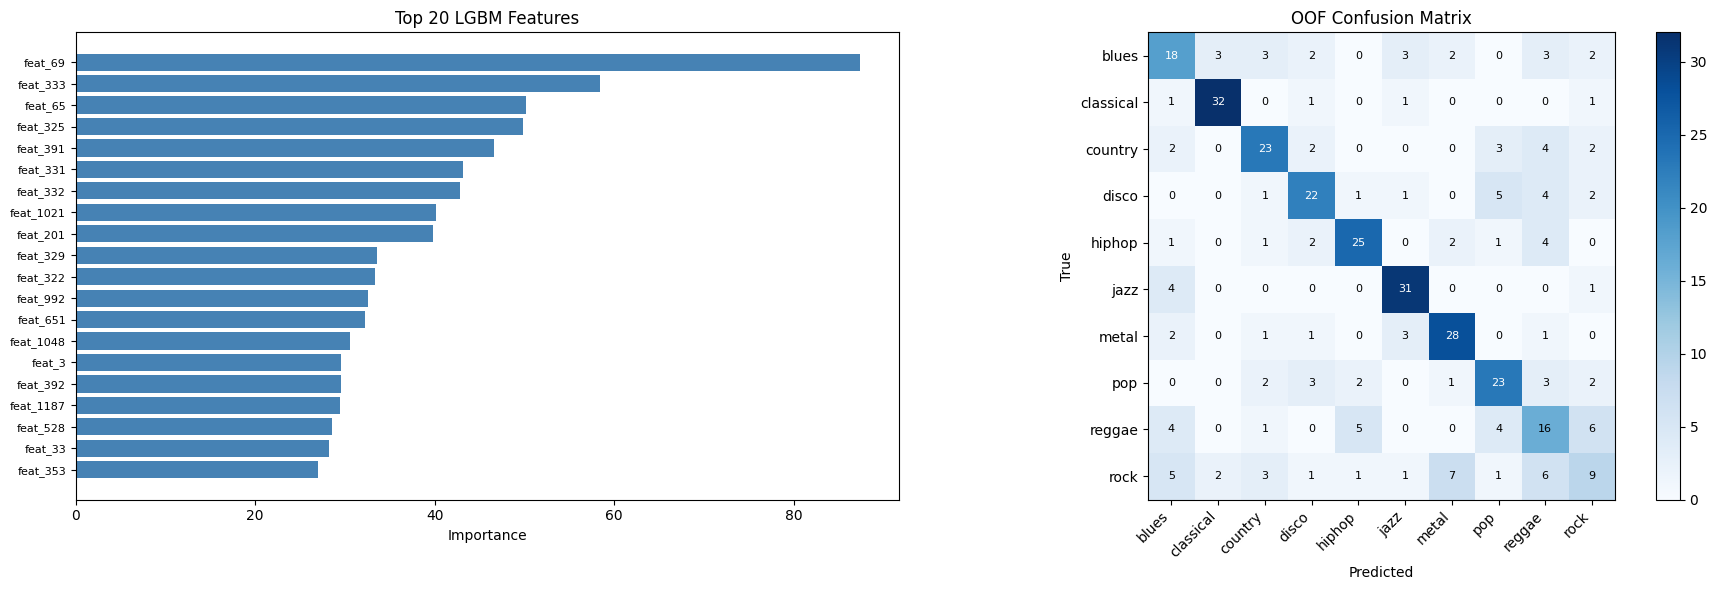

In [48]:
feat_imp = np.mean([m.feature_importances_ for m in models], axis=0)
top_n    = 20
top_idx  = np.argsort(feat_imp)[-top_n:][::-1]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].barh(range(top_n), feat_imp[top_idx][::-1], color='steelblue')
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels([f'feat_{i}' for i in top_idx[::-1]], fontsize=8)
axes[0].set_xlabel('Importance')
axes[0].set_title(f'Top {top_n} LGBM Features')

cm = confusion_matrix(y, oof_preds)
im = axes[1].imshow(cm, interpolation='nearest', cmap='Blues')
axes[1].set_xticks(range(NUM_LABELS)); axes[1].set_xticklabels(GENRES, rotation=45, ha='right')
axes[1].set_yticks(range(NUM_LABELS)); axes[1].set_yticklabels(GENRES)
axes[1].set_title('OOF Confusion Matrix')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
plt.colorbar(im, ax=axes[1])
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    axes[1].text(j, i, str(cm[i, j]), ha='center', va='center',
                 color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=8)

plt.tight_layout()


wandb.log({
    'lgbm_confusion_matrix':  wandb.Image(fig),
    'lgbm_feature_importance': wandb.plot.bar(
        wandb.Table(
            data=[[f'feat_{top_idx[i]}', float(feat_imp[top_idx[i]])] for i in range(top_n)],
            columns=['feature', 'importance']
        ),
        'feature', 'importance', title='LGBM Top Feature Importances'
    )
})
plt.show()

wandb.log({'lgbm_classification_report': wandb.Table(
    dataframe=pd.DataFrame(
        classification_report(y, oof_preds, target_names=GENRES, output_dict=True)
    ).T.reset_index().rename(columns={'index': 'genre'})
)})



In [49]:
noise_paths = [
    os.path.join(ESC_PATH, f)
    for f in os.listdir(ESC_PATH)
    if f.endswith('.wav')
] if os.path.isdir(ESC_PATH) else []
print(f'Noise files found: {len(noise_paths)} — pre-loading into RAM...')
noise_files = []
for _np in noise_paths:
    try:
        _a, _ = librosa.load(_np, sr=SAMPLE_RATE, mono=True)
        noise_files.append(_a.astype(np.float32))
    except Exception:
        pass
print(f'Noise files pre-loaded: {len(noise_files)}')

def load_audio(path, offset_sec=None):
    try:
        info      = sf.info(path)
        native_sr = info.samplerate
        if offset_sec is not None:
            start_frame = int(offset_sec * native_sr)
            n_frames    = int(MAX_LENGTH / SAMPLE_RATE * native_sr) + native_sr
            audio, _    = sf.read(path, start=start_frame,
                                  frames=n_frames, dtype='float32', always_2d=False)
        else:
            audio, _    = sf.read(path, dtype='float32', always_2d=False)
        if audio.ndim > 1:
            audio = audio.mean(axis=1)
        if native_sr != SAMPLE_RATE:
            audio = librosa.resample(audio, orig_sr=native_sr, target_sr=SAMPLE_RATE)
    except Exception:
        audio, _ = librosa.load(path, sr=SAMPLE_RATE, mono=True)
    return audio.astype(np.float32)

def normalize(audio):
    return audio / (np.max(np.abs(audio)) + 1e-6)

def crop_random(audio):
    if len(audio) >= MAX_LENGTH:
        start = random.randint(0, len(audio) - MAX_LENGTH)
        return audio[start : start + MAX_LENGTH]
    return np.pad(audio, (0, MAX_LENGTH - len(audio)))

def random_offset_sec(path):
    try:
        info     = sf.info(path)
        duration = info.frames / info.samplerate
        clip_dur = MAX_LENGTH / SAMPLE_RATE
        if duration > clip_dur:
            return random.uniform(0, duration - clip_dur)
    except Exception:
        pass
    return None

def crop_center(audio):
    if len(audio) >= MAX_LENGTH:
        start = (len(audio) - MAX_LENGTH) // 2
        return audio[start : start + MAX_LENGTH]
    return np.pad(audio, (0, MAX_LENGTH - len(audio)))

def random_gain(audio):
    return audio * random.uniform(0.7, 1.3)

def tempo_augment(audio):
    if random.random() < TEMPO_PROB:
        rate  = random.uniform(*TEMPO_RANGE)
        audio = librosa.effects.time_stretch(audio, rate=rate)
    return audio

def add_noise(audio):
    if random.random() < NOISE_PROB and len(noise_files) > 0:
        noise = crop_random(random.choice(noise_files))
        level = random.uniform(*NOISE_LEVEL)
        audio = audio + level * noise
    return audio

print('Audio helpers ready!')

Noise files found: 2000 — pre-loading into RAM...
Noise files pre-loaded: 2000
Audio helpers ready!


In [50]:
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

def spec_augment(mel, num_time_masks=2, num_freq_masks=2,
                  time_mask_width=30, freq_mask_width=20):
    mel = mel.copy()
    _, T = mel.shape
    F    = mel.shape[0]
    for _ in range(num_time_masks):
        t  = random.randint(0, time_mask_width)
        t0 = random.randint(0, max(T - t, 0))
        mel[:, t0:t0 + t] = 0
    for _ in range(num_freq_masks):
        f  = random.randint(0, freq_mask_width)
        f0 = random.randint(0, max(F - f, 0))
        mel[f0:f0 + f, :] = 0
    return mel

def audio_to_melspec(audio, augment=False):
    mel = librosa.feature.melspectrogram(
        y=audio, sr=SAMPLE_RATE,
        n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-6)

    if augment and SPEC_AUGMENT:
        mel_db = spec_augment(mel_db)

    mel_rgb = np.stack([mel_db, mel_db, mel_db], axis=-1).astype(np.float32)
    mel_rgb = (mel_rgb - mel_rgb.min()) / (mel_rgb.max() - mel_rgb.min() + 1e-6)

    if augment:
        img = train_transform(mel_rgb)
    else:
        img = val_transform(mel_rgb)
    return img

print('Mel-spectrogram helpers ready!')

Mel-spectrogram helpers ready!


In [ ]:
class SEBlock(nn.Module):
    
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(channels, channels // reduction, bias=False),
            nn.GELU(),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        scale = self.se(x).view(x.size(0), x.size(1), 1, 1)
        return x * scale


class ConvBlock(nn.Module):
    
    def __init__(self, in_ch, out_ch, reduction=8):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
        )
        self.se = SEBlock(out_ch, reduction)
        self.proj = (
            nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, bias=False),
                nn.BatchNorm2d(out_ch),
            )
            if in_ch != out_ch else nn.Identity()
        )

    def forward(self, x):
        return self.se(self.conv(x)) + self.proj(x)


class CustomCNN(nn.Module):
    
    def __init__(self, num_classes=NUM_LABELS, dropout1=0.4, dropout2=0.3):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.MaxPool2d(3, stride=2, padding=1),
        )

        self.block1 = nn.Sequential(
            ConvBlock(64,  64),
            nn.MaxPool2d(2),
        )
        self.block2 = nn.Sequential(
            ConvBlock(64,  128),
            nn.MaxPool2d(2),
        )
        self.block3 = nn.Sequential(
            ConvBlock(128, 256),
            nn.MaxPool2d(2),
        )
        self.block4 = nn.Sequential(
            ConvBlock(256, 512),
            nn.MaxPool2d(2),
        )
        self.block5 = ConvBlock(512, 512)

        self.gap = nn.AdaptiveAvgPool2d(1)
        self.gmp = nn.AdaptiveMaxPool2d(1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1024, 512, bias=False),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(dropout1),
            nn.Linear(512, 256, bias=False),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(dropout2),
            nn.Linear(256, num_classes),
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    @property
    def features(self):
        return nn.ModuleList([self.stem, self.block1, self.block2,
                              self.block3, self.block4, self.block5])

    def forward(self, x):
        x = self.stem(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)
        x = torch.cat([self.gap(x), self.gmp(x)], dim=1)
        return self.classifier(x)


model = CustomCNN(num_classes=NUM_LABELS).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f'CustomCNN on {DEVICE}')
print(f'Total parameters: {total_params:,}')

CustomCNN on cuda
Total parameters: 10,438,474


In [52]:
class TrainDataset(Dataset):
    def __init__(self, song_index, size=TRAIN_SIZE):
        self.song_index = song_index
        self.size       = size

    def __len__(self):
        return self.size

    def __getitem__(self, idx):
        while True:
            try:
                genre = random.choice(GENRES)
                songs = self.song_index[genre]
                if len(songs) == 0:
                    continue

                mixed = None
                for stem in REQUIRED_STEMS:
                    song_path  = random.choice(songs)
                    stem_path  = os.path.join(song_path, stem)
                    offset_sec = random_offset_sec(stem_path)
                    audio      = load_audio(stem_path, offset_sec=offset_sec)
                    audio      = crop_random(audio)
                    audio      = tempo_augment(audio)
                    audio      = random_gain(audio)
                    mixed      = audio if mixed is None else mixed + audio

                mixed = normalize(mixed)
                mixed = add_noise(mixed)
                mixed = normalize(mixed)

                img = audio_to_melspec(mixed, augment=True)
                return {
                    'pixel_values': img,
                    'labels'      : torch.tensor(label2id[genre], dtype=torch.long)
                }
            except Exception:
                continue

print('TrainDataset class defined!')

TrainDataset class defined!


In [53]:
class ValDataset(Dataset):
    def __init__(self, song_index):
        self.samples = []
        for genre in GENRES:
            for song_path in song_index[genre]:
                self.samples.append((genre, song_path))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        genre, song_path = self.samples[idx]
        mixed = None
        for stem in REQUIRED_STEMS:
            audio = load_audio(os.path.join(song_path, stem))
            audio = crop_center(audio)
            mixed = audio if mixed is None else mixed + audio

        mixed = normalize(mixed)
        img   = audio_to_melspec(mixed, augment=False)
        return {
            'pixel_values': img,
            'labels'      : torch.tensor(label2id[genre], dtype=torch.long)
        }

print('ValDataset class defined!')

ValDataset class defined!


In [54]:
train_dataset = TrainDataset(train_index, size=TRAIN_SIZE)
val_dataset   = ValDataset(val_index)

train_loader = DataLoader(
    train_dataset,
    batch_size         = BATCH_SIZE,
    shuffle            = True,
    num_workers        = NUM_WORKERS,
    pin_memory         = True,
    persistent_workers = True,
    prefetch_factor    = PREFETCH_FACTOR
)
val_loader = DataLoader(
    val_dataset,
    batch_size         = BATCH_SIZE,
    shuffle            = False,
    num_workers        = NUM_WORKERS,
    pin_memory         = True,
    persistent_workers = True,
    prefetch_factor    = PREFETCH_FACTOR
)

print(f'Train samples : {len(train_dataset)}')
print(f'Val samples   : {len(val_dataset)}')
print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')

Train samples : 5000
Val samples   : 150
Train batches : 209
Val batches   : 7


In [55]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
f1_metric = MulticlassF1Score(
    num_classes = NUM_LABELS,
    average     = 'macro'
).to(DEVICE)

print('Loss: CrossEntropyLoss with label_smoothing=0.1')
print('Metric: Macro F1 Score')

Loss: CrossEntropyLoss with label_smoothing=0.1
Metric: Macro F1 Score


In [56]:
def train_one_epoch(model, loader, optimizer, scheduler):
    model.train()
    f1_metric.reset()
    total_loss = 0
    optimizer.zero_grad()

    for step, batch in enumerate(tqdm(loader, desc='Training')):
        pixel_values = batch['pixel_values'].to(DEVICE)
        labels       = batch['labels'].to(DEVICE)

        logits = model(pixel_values)
        loss   = criterion(logits, labels) / GRAD_ACCUM
        loss.backward()

        if (step + 1) % GRAD_ACCUM == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        total_loss += loss.item() * GRAD_ACCUM
        preds = torch.argmax(logits, dim=1)
        f1_metric.update(preds, labels)

    return total_loss / len(loader), f1_metric.compute().item()


def validate(model, loader):
    model.eval()
    f1_metric.reset()
    with torch.no_grad():
        for batch in tqdm(loader, desc='Validation'):
            pixel_values = batch['pixel_values'].to(DEVICE)
            labels       = batch['labels'].to(DEVICE)
            logits       = model(pixel_values)
            preds        = torch.argmax(logits, dim=1)
            f1_metric.update(preds, labels)
    return f1_metric.compute().item()

print('train_one_epoch and validate functions ready!')

train_one_epoch and validate functions ready!


In [57]:
from torch.optim.lr_scheduler import CosineAnnealingLR

for m in [model.stem, model.block1, model.block2]:
    for p in m.parameters():
        p.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Phase 1: {trainable:,} params trainable (deep blocks + head)')

optimizer_p1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr           = LR_P1,
    weight_decay = WEIGHT_DECAY
)
total_steps_p1 = (len(train_loader) // GRAD_ACCUM) * EPOCHS_P1
scheduler_p1   = CosineAnnealingLR(optimizer_p1, T_max=total_steps_p1)

best_p1_f1   = 0
patience_cnt = 0

print(f'\n{"="*50}')
print(f'PHASE 1 — Head + Deep Blocks Warm-Up ({EPOCHS_P1} epochs)')
print(f'{"="*50}\n')

for epoch in range(EPOCHS_P1):
    train_loss, train_f1 = train_one_epoch(
        model, train_loader, optimizer_p1, scheduler_p1
    )
    val_f1 = validate(model, val_loader)

    print(f'Epoch {epoch+1}/{EPOCHS_P1}')
    print(f'  Train Loss : {train_loss:.4f}')
    print(f'  Train F1   : {train_f1:.4f}')
    print(f'  Val F1     : {val_f1:.4f}')

    wandb.log({
        'phase1/train_loss': train_loss,
        'phase1/train_f1'  : train_f1,
        'phase1/val_f1'    : val_f1,
        'phase1/epoch'     : epoch + 1,
    })

    if val_f1 > best_p1_f1:
        best_p1_f1   = val_f1
        torch.save(model.state_dict(), '/kaggle/working/best_model_phase1.pth')
        patience_cnt = 0
        print(f'  Saved best Phase 1 model (val F1: {best_p1_f1:.4f})')
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE_P1:
            print('  Early stopping Phase 1.')
            break

print(f'\nPhase 1 done! Best val F1: {best_p1_f1:.4f}')

Phase 1: 10,119,690 params trainable (deep blocks + head)

PHASE 1 — Head + Deep Blocks Warm-Up (5 epochs)



Validation: 100%|██████████| 7/7 [00:20<00:00,  2.96s/it]


Epoch 1/5
  Train Loss : 1.4762
  Train F1   : 0.5685
  Val F1     : 0.6589
  Saved best Phase 1 model (val F1: 0.6589)


Validation: 100%|██████████| 7/7 [00:20<00:00,  2.99s/it]


Epoch 2/5
  Train Loss : 1.1638
  Train F1   : 0.7115
  Val F1     : 0.6823
  Saved best Phase 1 model (val F1: 0.6823)


...

Epoch 3/5
  Train Loss : 1.0402
  Train F1   : 0.7673
  Val F1     : 0.7027
  Saved best Phase 1 model (val F1: 0.7027)


Validation: 100%|██████████| 7/7 [00:19<00:00,  2.78s/it]


Epoch 4/5
  Train Loss : 0.9751
  Train F1   : 0.8032
  Val F1     : 0.7297
  Saved best Phase 1 model (val F1: 0.7297)


Validation: 100%|██████████| 7/7 [00:20<00:00,  2.90s/it]

Epoch 5/5
  Train Loss : 0.9201
  Train F1   : 0.8233
  Val F1     : 0.7351
  Saved best Phase 1 model (val F1: 0.7351)

Phase 1 done! Best val F1: 0.7351


In [58]:
model.load_state_dict(torch.load('/kaggle/working/best_model_phase1.pth'))

for param in model.parameters():
    param.requires_grad = True

total_params = sum(p.numel() for p in model.parameters())
print(f'All {total_params:,} params unfrozen!')

optimizer_p2 = torch.optim.AdamW([
    {'params': model.stem.parameters(),       'lr': LR_P2 * 0.1},
    {'params': model.block1.parameters(),     'lr': LR_P2 * 0.2},
    {'params': model.block2.parameters(),     'lr': LR_P2 * 0.4},
    {'params': model.block3.parameters(),     'lr': LR_P2 * 0.7},
    {'params': model.block4.parameters(),     'lr': LR_P2},
    {'params': model.block5.parameters(),     'lr': LR_P2},
    {'params': model.classifier.parameters(), 'lr': LR_P2},
], weight_decay=WEIGHT_DECAY)

total_steps_p2 = (len(train_loader) // GRAD_ACCUM) * EPOCHS_P2
scheduler_p2   = CosineAnnealingLR(optimizer_p2, T_max=total_steps_p2)

best_p2_f1   = 0
patience_cnt = 0

print(f'\n{"="*50}')
print(f'PHASE 2 — Full Fine-Tune ({EPOCHS_P2} epochs)')
print(f'Differential LRs: stem={LR_P2*0.1:.1e} ... head={LR_P2:.1e}')
print(f'{"="*50}\n')

for epoch in range(EPOCHS_P2):
    train_loss, train_f1 = train_one_epoch(
        model, train_loader, optimizer_p2, scheduler_p2
    )
    val_f1 = validate(model, val_loader)

    print(f'Epoch {epoch+1}/{EPOCHS_P2}')
    print(f'  Train Loss : {train_loss:.4f}')
    print(f'  Train F1   : {train_f1:.4f}')
    print(f'  Val F1     : {val_f1:.4f}')

    wandb.log({
        'phase2/train_loss': train_loss,
        'phase2/train_f1'  : train_f1,
        'phase2/val_f1'    : val_f1,
        'phase2/epoch'     : epoch + 1,
    })

    if val_f1 > best_p2_f1:
        best_p2_f1   = val_f1
        torch.save(model.state_dict(), '/kaggle/working/best_model_phase2.pth')
        wandb.run.summary['best_val_f1_p2'] = best_p2_f1
        patience_cnt = 0
        print(f'  Saved best Phase 2 model (val F1: {best_p2_f1:.4f})')
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE_P2:
            print('  Early stopping Phase 2.')
            break

print(f'\nPhase 2 done! Best val F1: {best_p2_f1:.4f}')

All 10,438,474 params unfrozen!

PHASE 2 — Full Fine-Tune (10 epochs)
Differential LRs: stem=3.0e-05 ... head=3.0e-04



Validation: 100%|██████████| 7/7 [00:20<00:00,  2.87s/it]


Epoch 1/10
  Train Loss : 0.9343
  Train F1   : 0.8242
  Val F1     : 0.7319
  Saved best Phase 2 model (val F1: 0.7319)


Validation: 100%|██████████| 7/7 [00:20<00:00,  2.89s/it]


Epoch 2/10
  Train Loss : 0.9056
  Train F1   : 0.8291
  Val F1     : 0.7138


...

Epoch 8/10
  Train Loss : 0.7716
  Train F1   : 0.8977
  Val F1     : 0.7800


Validation: 100%|██████████| 7/7 [00:20<00:00,  2.97s/it]


Epoch 9/10
  Train Loss : 0.7584
  Train F1   : 0.8997
  Val F1     : 0.7999
  Saved best Phase 2 model (val F1: 0.7999)


Validation: 100%|██████████| 7/7 [00:20<00:00,  2.94s/it]

Epoch 10/10
  Train Loss : 0.7565
  Train F1   : 0.9057
  Val F1     : 0.8053
  Saved best Phase 2 model (val F1: 0.8053)

Phase 2 done! Best val F1: 0.8053


In [59]:
def predict_with_tta(model, audio, n_tta=N_TTA):
    model.eval()
    all_probs = []
    for _ in range(n_tta):
        cropped = crop_random(audio)
        cropped = normalize(cropped)
        img     = audio_to_melspec(cropped, augment=False)
        img     = img.unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            logits = model(img)
            probs  = torch.softmax(logits, dim=1)
            all_probs.append(probs.cpu().numpy())

    avg_probs = np.mean(all_probs, axis=0)
    return np.argmax(avg_probs, axis=1)[0]

print(f'TTA function ready! Using {N_TTA} crops per prediction.')

TTA function ready! Using 5 crops per prediction.


In [60]:
model.load_state_dict(torch.load('/kaggle/working/best_model_phase2.pth'))
model.eval()
print(f'Best model loaded! Val F1 was: {best_p2_f1:.4f}')

test_df   = pd.read_csv(os.path.join(BASE_PATH, 'test.csv'))
print(f'Test samples: {len(test_df)}')

all_ids   = []
all_preds = []

for idx in tqdm(range(len(test_df)), desc=f'Inference (TTA x{N_TTA})'):
    row   = test_df.iloc[idx]
    path  = os.path.join(BASE_PATH, row['filename'])
    audio = load_audio(path)
    pred  = predict_with_tta(model, audio, n_tta=N_TTA)
    all_ids.append(row['id'])
    all_preds.append(id2label[pred])

submission = pd.DataFrame({'id': all_ids, 'genre': all_preds})
print(f'\nSubmission ready!')
print(f'Total predictions : {len(submission)}')
print(f'\nGenre distribution:')
print(submission['genre'].value_counts())
print(f'\nFirst 5 predictions:')
print(submission.head())

Best model loaded! Val F1 was: 0.8053
Test samples: 3020


Inference (TTA x5): 100%|██████████| 3020/3020 [12:41<00:00,  3.96it/s]



Submission ready!
Total predictions : 3020

Genre distribution:
genre
rock         708
hiphop       394
pop          305
disco        299
metal        295
reggae       256
jazz         243
blues        203
classical    199
country      118
Name: count, dtype: int64

First 5 predictions:
   id    genre
0   1      pop
1   2     jazz
2   3    disco
3   4    metal
4   5  country


In [61]:
print('='*50)
print('TRAINING COMPLETE!')
print('='*50)
print(f'  Phase 1 best val F1 : {best_p1_f1:.4f}')
print(f'  Phase 2 best val F1 : {best_p2_f1:.4f}')
print(f'  TTA crops used      : {N_TTA}')
print(f'  Expected Kaggle F1  : ~{best_p2_f1 + 0.01:.4f}')
print('='*50)
print()
print('To improve further, try:')
print('  DURATION    = 25       (more audio context)')
print('  N_MELS      = 256      (richer spectrogram)')
print('  TRAIN_SIZE  = 8000     (more diversity)')
print('  EPOCHS_P2   = 15       (more time to converge)')
print('  LR_P2       = 2e-4     (tune if over-fitting)')
print('  N_TTA       = 8        (smoother inference probs)')

TRAINING COMPLETE!
  Phase 1 best val F1 : 0.7351
  Phase 2 best val F1 : 0.8053
  TTA crops used      : 5
  Expected Kaggle F1  : ~0.8153

To improve further, try:
  DURATION    = 25       (more audio context)
  N_MELS      = 256      (richer spectrogram)
  TRAIN_SIZE  = 8000     (more diversity)
  EPOCHS_P2   = 15       (more time to converge)
  LR_P2       = 2e-4     (tune if over-fitting)
  N_TTA       = 8        (smoother inference probs)


In [62]:
submission.to_csv('/kaggle/working/submission.csv', index=False)

In [63]:
from IPython.display import FileLink
FileLink('/kaggle/working/submission.csv')

/kaggle/working/submission.csv

In [64]:
wandb.finish()

lgbm_dataset_size,▁
lgbm_fold1_best_iteration,▁
lgbm_fold1_macro_f1,▁
lgbm_fold2_best_iteration,▁
lgbm_fold2_macro_f1,▁
lgbm_fold3_best_iteration,▁
lgbm_fold3_macro_f1,▁
lgbm_fold4_best_iteration,▁
lgbm_fold4_macro_f1,▁
lgbm_fold5_best_iteration,▁
+10,...
